# Lab Assignment - 2
**Course:** B. Tech Type- Specialization Elective  
**Course Code:** CSET343  
**Course Name:** AI in Healthcare  
**Year:** 4th Year  
**Semester:** VII  

**Objective:** Perform data cleaning and enrichment on a sample clinical dataset with missing values.  
**Dataset:** Heart Failure Dataset (Heart Failure Clinical Records Dataset)


### 1. Dataset Acquisition
Download Heart Failure Clinical Records Dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Dataset file path
data_path = "heart_failure_clinical_records_dataset.csv"


### 2. Load Dataset
Read dataset as pandas DataFrame, display first 5 rows.


In [2]:
df = pd.read_csv(data_path)
df_before = df.copy() # Store copy for before/after comparison
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


### 3. Summarize Dataset
Report number of rows, columns, data types, missing values.


In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing values count per column:")
print(df.isnull().sum())


Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values count per column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


### 4. Visualize Missing Values
Create heatmap using seaborn to show missing values.


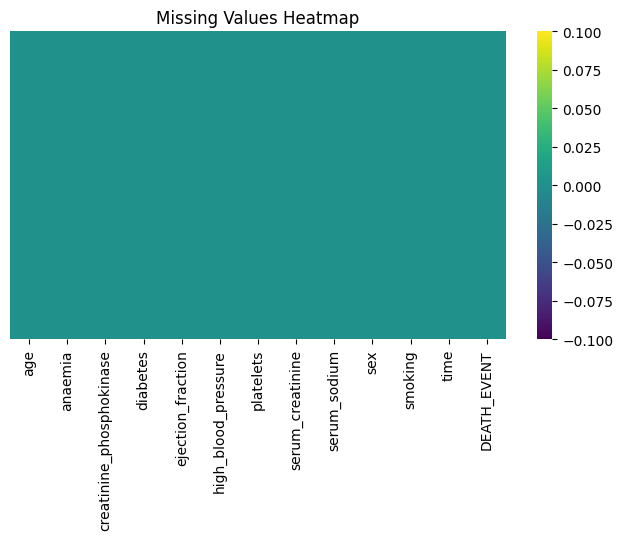

In [4]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


### 5. Plot Distributions
Generate histograms or boxplots for numerical features (e.g., age, ejection_fraction).


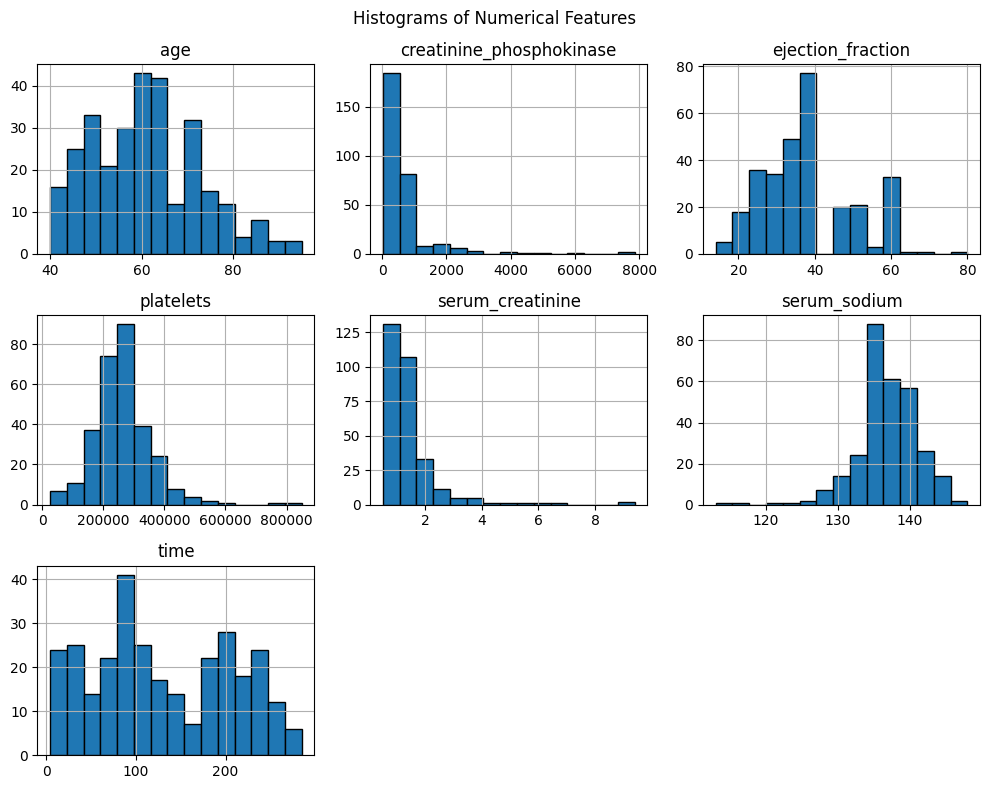

In [5]:
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 
                  'platelets', 'serum_creatinine', 'serum_sodium', 'time']

# Histograms
df[numerical_cols].hist(figsize=(10, 8), bins=15, edgecolor='black')
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()


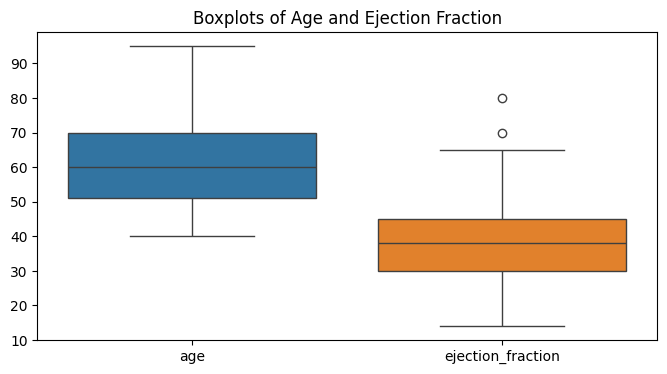

In [6]:
# Boxplots for numerical features (e.g., age, ejection_fraction)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[['age', 'ejection_fraction']])
plt.title("Boxplots of Age and Ejection Fraction")
plt.show()


### 6. Impute Missing Values
- **Numerical features:** Use mean or median (e.g., serum_creatinine).
- **Categorical features:** Use mode or "Unknown" (e.g., smoking).


In [7]:
# Impute numerical features using median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Impute categorical features using mode
categorical_cols = ['sex', 'smoking', 'anaemia', 'diabetes', 'high_blood_pressure']
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation check:")
print(df.isnull().sum())


Missing values after imputation check:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


### 7. Remove Outliers
Identify and remove outliers using the IQR method.


In [8]:
# Remove outliers for continuous features using IQR
for col in ['ejection_fraction', 'serum_creatinine', 'platelets']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Shape after removing outliers: {df.shape}")


Shape after removing outliers: (251, 13)


### 8. Correct Inconsistencies
Check and fix invalid entries (e.g., negative age).


In [9]:
# Check and fix invalid entries
df = df[df['age'] > 0]
df['age'] = df['age'].astype(int)

# Ensure ejection_fraction is within valid range (0-100)
df = df[(df['ejection_fraction'] >= 0) & (df['ejection_fraction'] <= 100)]
print(f"Shape after correcting inconsistencies: {df.shape}")


Shape after correcting inconsistencies: (251, 13)


### 9. Feature Engineering
- Create `age_group` feature (bins: <40, 40–60, >60).
- Create `risk_score` feature (e.g., normalized product of ejection_fraction, serum_creatinine).


In [10]:
# 1. Create age_group feature (bins: <40, 40–60, >60)
df['age_group'] = pd.cut(df['age'], bins=[0, 39, 60, 120], labels=['<40', '40–60', '>60'])

# 2. Create risk_score feature (normalized product of ejection_fraction, serum_creatinine)
product = df['ejection_fraction'] * df['serum_creatinine']
df['risk_score'] = (product - product.min()) / (product.max() - product.min())

df[['age', 'age_group', 'ejection_fraction', 'serum_creatinine', 'risk_score']].head()


,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75,>60,20,1.9,0.287245
1,55,40–60,38,1.1,0.327974
2,65,>60,20,1.3,0.158628
3,50,40–60,20,1.9,0.287245
5,90,>60,40,2.1,0.780279


### 10. Encode Categorical Variables
Apply one-hot or label encoding to categorical features (e.g., sex, smoking).


In [11]:
# Label encoding on age_group
le = LabelEncoder()
df['age_group_encoded'] = le.fit_transform(df['age_group'])

# One-hot encoding on categorical features
df = pd.get_dummies(df, columns=['sex', 'smoking', 'age_group'], drop_first=False)
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,age_group_encoded,sex_0,sex_1,smoking_0,smoking_1,age_group_<40,age_group_40–60,age_group_>60
0,75,0,582,0,20,1,265000.00,1.9,130,4,1,0.287245,1,False,True,True,False,False,False,True
1,55,0,7861,0,38,0,263358.03,1.1,136,6,1,0.327974,0,False,True,True,False,False,True,False
2,65,0,146,0,20,0,162000.00,1.3,129,7,1,0.158628,1,False,True,False,True,False,False,True
3,50,1,111,0,20,0,210000.00,1.9,137,7,1,0.287245,0,False,True,True,False,False,True,False
5,90,1,47,0,40,1,204000.00,2.1,132,8,1,0.780279,1,False,True,False,True,False,False,True


### 11. Normalize Features
Scale numerical features (e.g., age, platelets) to 0–1 using `MinMaxScaler`.


In [12]:
scaler = MinMaxScaler()
scale_cols = ['age', 'platelets', 'creatinine_phosphokinase', 'serum_sodium', 'time', 'ejection_fraction', 'serum_creatinine']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].head()


,age,platelets,creatinine_phosphokinase,serum_sodium,time,ejection_fraction,serum_creatinine
0,0.636364,0.523529,0.070489,0.485714,0.000000,0.117647,0.875
1,0.272727,0.518700,1.000000,0.657143,0.007117,0.470588,0.375
2,0.454545,0.220588,0.014813,0.457143,0.010676,0.117647,0.500
3,0.181818,0.361765,0.010344,0.685714,0.010676,0.117647,0.875
5,0.909091,0.344118,0.002171,0.542857,0.014235,0.509804,1.000


### 12. Compute Summary Statistics
Calculate mean, median, standard deviation before and after cleaning.


In [13]:
print("--- Summary Statistics Before Cleaning ---")
stats_before = df_before[numerical_cols].agg(['mean', 'median', 'std']).T
display(stats_before.round(2))

print("\n--- Summary Statistics After Cleaning ---")
stats_after = df[scale_cols].agg(['mean', 'median', 'std']).T
display(stats_after.round(2))


--- Summary Statistics Before Cleaning ---


,mean,median,std
age,60.83,60.0,11.89
creatinine_phosphokinase,581.84,250.0,970.29
ejection_fraction,38.08,38.0,11.83
platelets,263358.03,262000.0,97804.24
serum_creatinine,1.39,1.1,1.03
serum_sodium,136.63,137.0,4.41
time,130.26,115.0,77.61



--- Summary Statistics After Cleaning ---


,mean,median,std
age,0.37,0.36,0.22
platelets,0.50,0.52,0.20
creatinine_phosphokinase,0.07,0.03,0.13
serum_sodium,0.68,0.69,0.12
time,0.46,0.41,0.27
ejection_fraction,0.47,0.47,0.23
serum_creatinine,0.39,0.38,0.21


### 13. Validate Cleaning
Plot histograms or boxplots for cleaned numerical features.


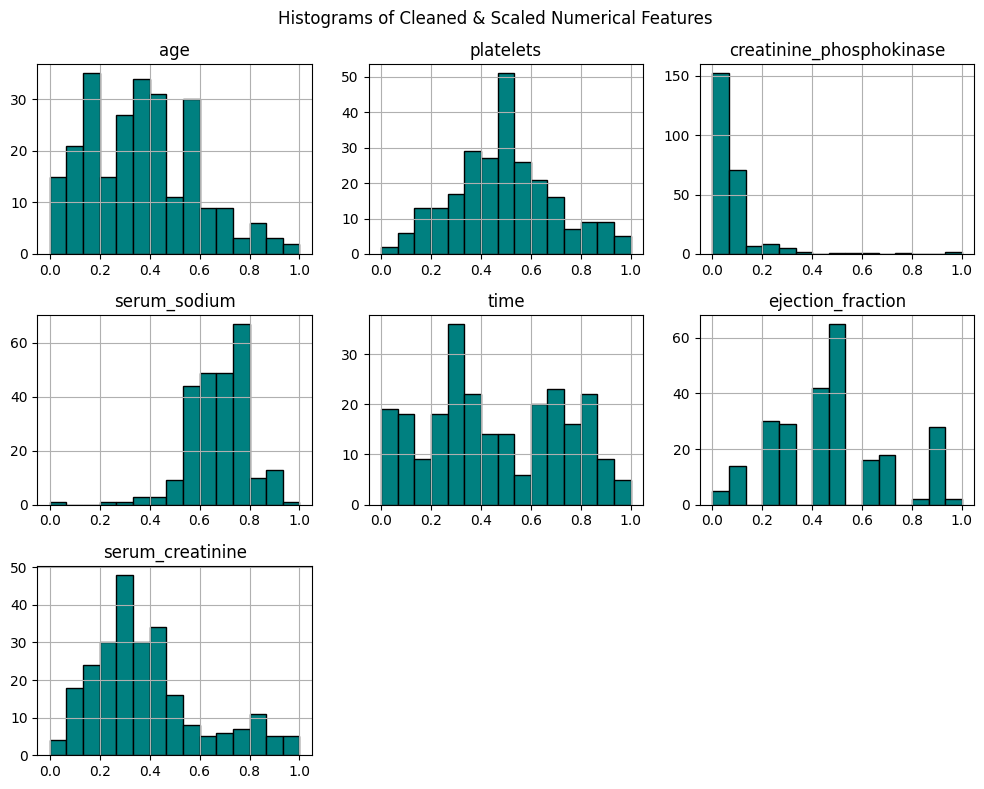

In [14]:
# Plot histograms for cleaned numerical features
df[scale_cols].hist(figsize=(10, 8), bins=15, edgecolor='black', color='teal')
plt.suptitle("Histograms of Cleaned & Scaled Numerical Features")
plt.tight_layout()
plt.show()


### 14. Check Missing Values
Confirm no missing values remain or justify any remaining.


In [15]:
print("Missing values in cleaned dataset:")
print(df.isnull().sum())
print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")
print("Result: Confirmed no missing values remain in the dataset.")

# Save cleaned dataset to CSV
df.to_csv("heart_failure_cleaned.csv", index=False)
print("Saved cleaned dataset to 'heart_failure_cleaned.csv'")


Missing values in cleaned dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_encoded           0
sex_0                       0
sex_1                       0
smoking_0                   0
smoking_1                   0
age_group_<40               0
age_group_40–60             0
age_group_>60               0
dtype: int64

Total missing values remaining: 0
Result: Confirmed no missing values remain in the dataset.


Saved cleaned dataset to 'heart_failure_cleaned.csv'
